<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen "Papulator" auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 29.04.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)
    * [Aufgabe 5](#Aufgabe-5)
    * [Aufgabe 6](#Aufgabe-6)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [175]:
versuchsnummer = "000"
versuchsname = "Beispielhafter-Name" # Auf Leerzeichen verzichten
aufgabe = "0z"
plt_save_folder = f"../img/plots/"

# Import aller genutzen Libaries

In [176]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import const
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

In [177]:
d_H = 0.295 # m
r_H = d_H/2 # m
A_H = np.pi * r_H**2 # m^2
x_H = 0.747 # m
n_H = 127
n_I = 4000
A_I = 0.00417 # m^2

<hr>

## Aufgabe 1

<hr>

## Aufgabe 2

In [178]:
dreh_frq = 10.10
err_dreh_frq = 0.20

# Spannung in der Helmutspule
I_H = 4 # A
err_I_H = 0.05 # A

# Induzierte Spannung in Abhänigkeit der Frquenz
freq = np.array([4.62, 6.15, 9.49, 12.09, 15.03]) * (2 * np.pi) # Hz
err_freq = 0.20 * (2 * np.pi) # Hz

U_M_f = np.array([1.80, 2.96, 5.60, 7.60, 9.92])/2 # V
err_U_M = 0.10 # V

# Induzierte Spannung in Abhänigkeit der Stromstärke
I = np.array([0.50, 1.00, 1.50, 2,  2.5, 3, 3.5, 4, 4.5]) # A
err_I = 0.05 # A

U_M_I = np.array([0.788, 1.68, 2.40, 3.20, 3.88, 4.64, 5.36, 6.20, 7.04])/2 # V

In [179]:
def linear(m,x,b):
    return m*x+b

Steigung: (6.21 \pm 0.19) 10^-2 Vs


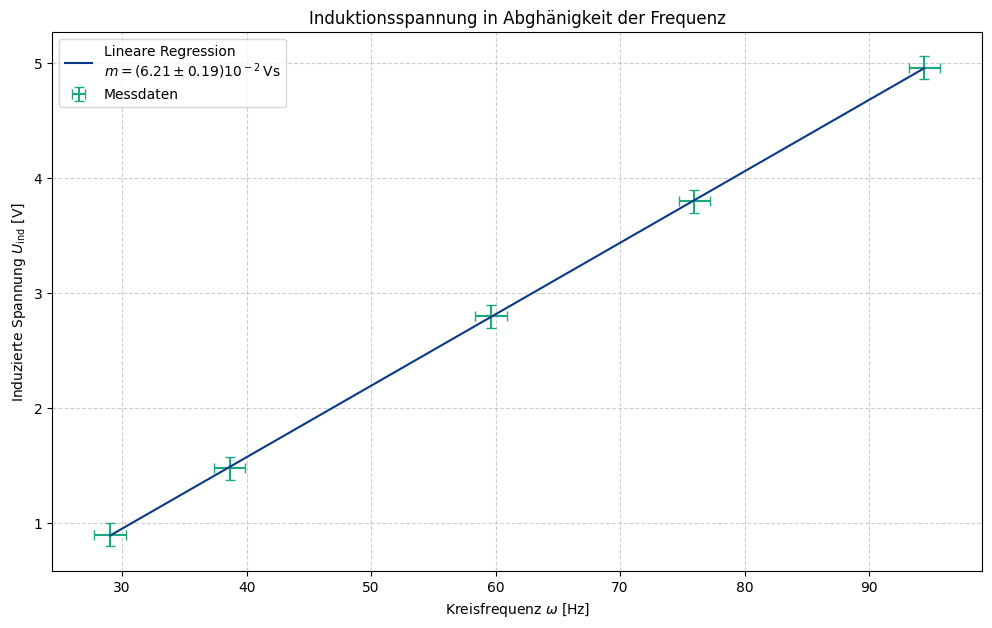

<Axes: title={'center': 'Induktionsspannung in Abghänigkeit der Frequenz'}, xlabel='Kreisfrequenz $\\omega$ [Hz]', ylabel='Induzierte Spannung $U_\\text{ind}$ [V]'>

In [180]:
plt.figure(figsize=(12,7))

plt.errorbar(
    freq,
    U_M_f,
    err_U_M,
    err_freq,
    ls= ' ',
    capsize=3.5,
    label='Messdaten'
    )

# Regression
popt1, pcov1 = curve_fit(linear, freq, U_M_f, sigma = err_U_M, absolute_sigma = True)
m = popt1[0]
err_m = np.sqrt(pcov1[0][0])

expo = 1e2
print(f"Steigung: ({pap.round_sig_digs(err_m * expo, m * expo)[2]}) 10^{-(len(str(expo)) - 3)} Vs")

plt.plot(
    freq,
    linear(freq, * popt1),
    label = f'Lineare Regression\n$m=({pap.round_sig_digs(err_m * expo, m * expo)[2]}) {{10^-}}^{(len(str(expo)) - 3)} \\, \\mathrm{{Vs}}$'
)

pap.plot_me(r'Induktionsspannung in Abghänigkeit der Frequenz', r'Kreisfrequenz $\omega$ [Hz]', r'Induzierte Spannung $U_\text{ind}$ [V]', fr'{plt_save_folder}Induk_durhc_Freq')

In [181]:
# Bestimmung des Magnetfeldes aus der Drehfrequenz
mag_feld = sym.m / (sym.A * sym.N)

values = np.array([
    m, err_m,
    A_I,
    n_I
])

temp = pap.do_it(mag_feld, [sym.m, sym.A, sym.N], values, [sym.A, sym.N], True)

B_feld = temp[0][0]
err_B_feld = temp[0][1]

expo = 1e3
print(f'Magnetfeldstärke: ({pap.round_sig_digs(err_B_feld * expo, B_feld * expo)[2]}) 10^{len(str(expo)) - 3} T')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
Magnetfeldstärke: (3.72 \pm 0.11) 10^3 T


In [182]:
alt_mag_feld = sym.mu * (8 / sp.sqrt(125)) * (sym.I *sym.N / sym.r)

values = np.array([
    I_H, err_I_H,
    const.mu_0, const.err_mu_0,
    n_H,
    r_H,
])

temp = pap.do_it(alt_mag_feld, [sym.I, sym.mu, sym.N, sym.r], values, [sym.N, sym.r], True)

alt_B_feld = temp[0][0]
err_alt_B_feld = temp[0][1]

expo = 1e3
print(f'Magnetfeldstärke: ({pap.round_sig_digs(err_alt_B_feld * expo, alt_B_feld * expo)[2]}) 10^{len(str(expo)) - 3} T')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
Magnetfeldstärke: (3.10 \pm 0.04) 10^3 T


In [183]:
# Abweichungen
print(f'Abweichung zwischen den beiden Feldstärken: {pap.std_abw(alt_B_feld, B_feld, err_alt_B_feld, err_B_feld)}')

Abweichung zwischen den beiden Feldstärken: 5.28


Steigung: (7.7 \pm 0.3) 10^-1 Vs


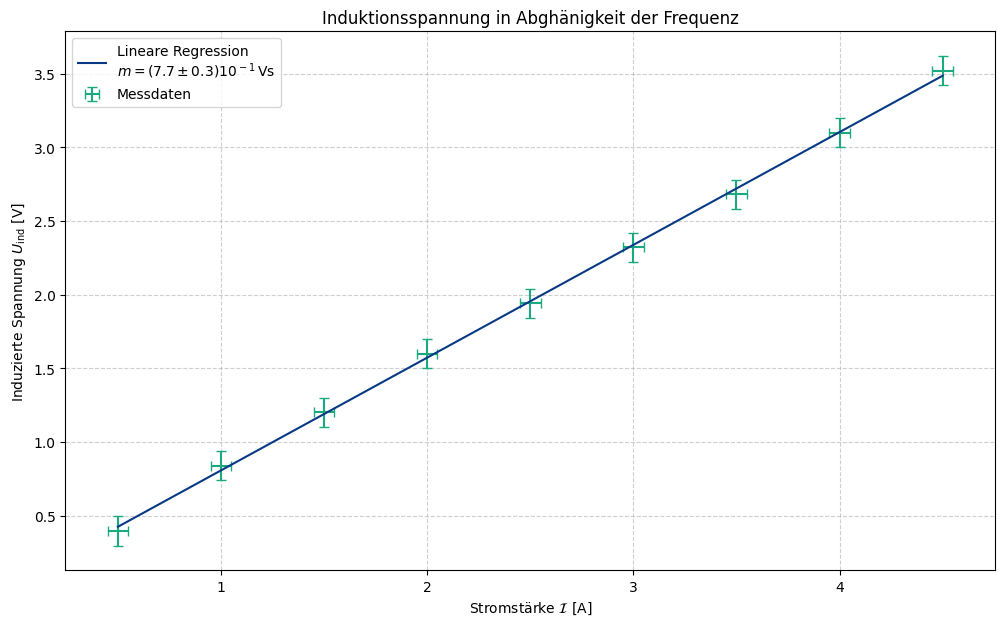

<Axes: title={'center': 'Induktionsspannung in Abghänigkeit der Frequenz'}, xlabel='Stromstärke $\\mathcal{I}$ [A]', ylabel='Induzierte Spannung $U_\\text{ind}$ [V]'>

In [184]:
plt.figure(figsize=(12,7))

plt.errorbar(
    I,
    U_M_I,
    err_U_M,
    err_I,
    ls= ' ',
    capsize=3.5,
    label='Messdaten'
    )

# Regression
popt1, pcov1 = curve_fit(linear, I, U_M_I, sigma = err_U_M, absolute_sigma = True)
m_I = popt1[0]
err_m_I = np.sqrt(pcov1[0][0])

expo = 1e1
print(f"Steigung: ({pap.round_sig_digs(err_m_I * expo, m_I * expo)[2]}) 10^{-(len(str(expo)) - 3)} Vs")

plt.plot(
    I,
    linear(I, * popt1),
    label = f'Lineare Regression\n$m=({pap.round_sig_digs(err_m_I * expo, m_I * expo)[2]}) {{10^-}}^{len(str(expo)) - 3} \\, \\mathrm{{Vs}}$'
)

pap.plot_me(r'Induktionsspannung in Abghänigkeit der Frequenz', r'Stromstärke $\mathcal{I}$ [A]', r'Induzierte Spannung $U_\text{ind}$ [V]', fr'{plt_save_folder}Induk_durcg_Strom')

<hr>

## Aufgabe 3

In [185]:
# Freq der Wechselspannung 
freq_U = 101.70 # Hz
err_freq_U = 0.20 # Hz

# Induzierte Spannung in Abhänigkeit des Drehwinkels
winkel = np.array([0, 30, 60, 90, 120, 150, 180]) # deg
err_winkel = 2.5 # deg

U_M_winkel = np.array([0.39, 0.35, 0.20, 0.06, 0.22, 0.36, 0.40])/2 # V
err_U_M_winkel = 0.05/2 # V


# Tab 3.3
freq_A3 = np.array([20.5, 40, 89.8, 80.6, 100.7, 120.4, 141.1, 160.4, 180.2, 200.8, 400.6, 602, 806.40, 1000, 1200, 1400]) * (2 * np.pi) # Hz
err_freq_A3 = 0.10 * (2 * np.pi) # Hz

U_Ind = np.array([0.42, 0.74, 0.99, 1.16, 1.26, 1.32, 1.36, 1.40, 1.42, 1.48, 1.54, 1.56, 1.56, 1.56, 1.56, 1.58])/2 # V
err_U_Ind = 0.05/2 # V

U_M_A3 = np.array([21.6, 20.6, 21.8, 22.6, 22.8, 22.6, 22.4, 22, 22.2, 22.2, 22.2, 22.2, 22.2, 22.2, 22.2, 22.2])/2 # V

I_A3 = np.array([86.2, 75.6, 68.8, 59.2, 51.6, 45.3, 40, 35.9, 32.6, 29.5, 15.6, 10.4, 7.8, 6.3, 5.2, 4.5]) * sqrt(2) # A
err_I_A3 = 0.05 * sqrt(2)  # A

In [186]:
def reg_ind(alpha, A, phi, d):
    return A * np.abs(np.cos((alpha - phi) * 2 * np.pi / 360)) + d

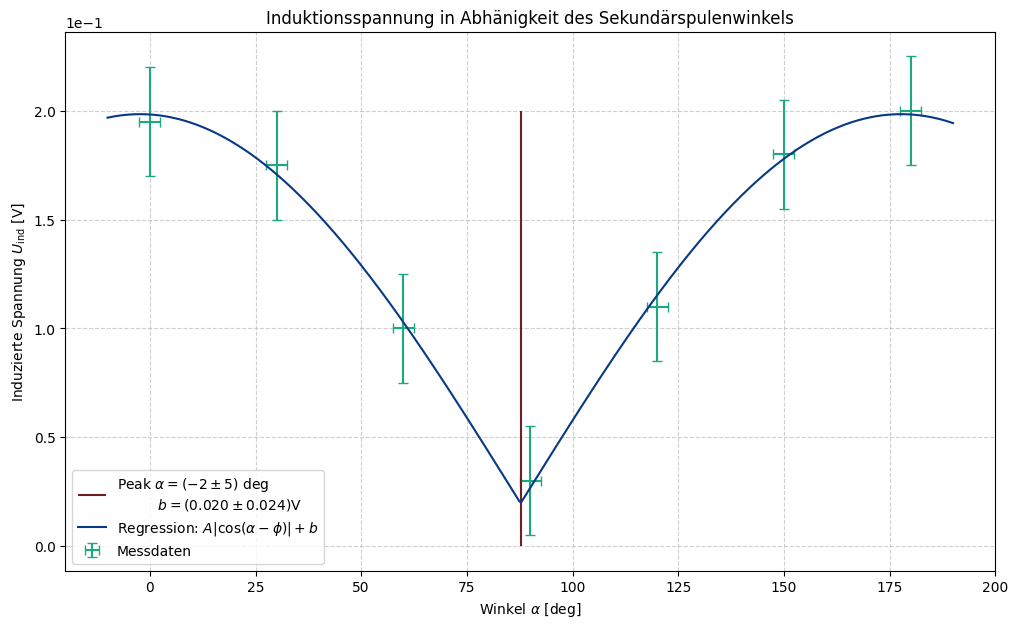

<Axes: title={'center': 'Induktionsspannung in Abhänigkeit des Sekundärspulenwinkels'}, xlabel='Winkel $\\alpha$ [deg]', ylabel='Induzierte Spannung $U_\\text{ind}$ [V]'>

In [187]:
plt.figure(figsize=(12,7))

plt.errorbar(
    winkel,
    U_M_winkel,
    err_U_M_winkel,
    err_winkel,
    ls= ' ',
    capsize=3.5,
    label='Messdaten'
    )

# Regression
popt, pcov = curve_fit(reg_ind, winkel, U_M_winkel, sigma = err_U_M_winkel, absolute_sigma = True)

# Offsetzs bestimmen
offset_phi = popt[1]
offset_b = popt[2]

err_offset_phi = sqrt(pcov[1, 1])
err_offset_b = sqrt(pcov[2, 2])

plt.vlines(90 + offset_phi, 0, 0.2,
           colors=c.WINE_RED,
           label=f'Peak $\\alpha = ({pap.round_sig_digs(err_offset_phi, offset_phi)[2]})$ deg\n$\\qquad\\quad b = ({pap.round_sig_digs(err_offset_b, offset_b)[2]})$V')

alpha_space = np.linspace(-10, 190, 500)
plt.plot(
    alpha_space,
    reg_ind(alpha_space, *popt),
    label = fr'Regression: $A|\cos(\alpha - \phi)|+b$'
)


pap.plot_me('Induktionsspannung in Abhänigkeit des Sekundärspulenwinkels', r'Winkel $\alpha$ [deg]', r'Induzierte Spannung $U_\text{ind}$ [V]', fr'{plt_save_folder}Induk_durch_Winkel')

In [188]:
residuals = U_M_winkel - reg_ind(winkel, *popt)
chi2_reduced = np.sum((residuals / err_U_M_winkel)**2) / (len(winkel) - len(popt))
print(f"Reduzierter Chi-Quadrat-Wert: {chi2_reduced:.4f}")

Reduzierter Chi-Quadrat-Wert: 0.0322


In [189]:
# Skaliere pcov mit χ^2_red 
pcov_scaled = pcov * chi2_reduced
d_error_realistic = np.sqrt(pcov_scaled[2, 2])

print(f'{d_error_realistic:.4f}')

0.0043


In [190]:
sym_U_ind, sym_U_H = sp.symbols(r'U_\text{ind}, U_H')

verh = sym_U_ind/sym_U_H

values = np.column_stack([
    U_Ind, [err_U_Ind] * len(U_Ind),
    U_M_A3, [err_U_M]  * len(U_M_A3)
])


temp = pap.do_it(verh, [sym_U_ind, sym_U_H], values, print_formula=True)

val = temp[:,0]
err = temp[:,1]

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------


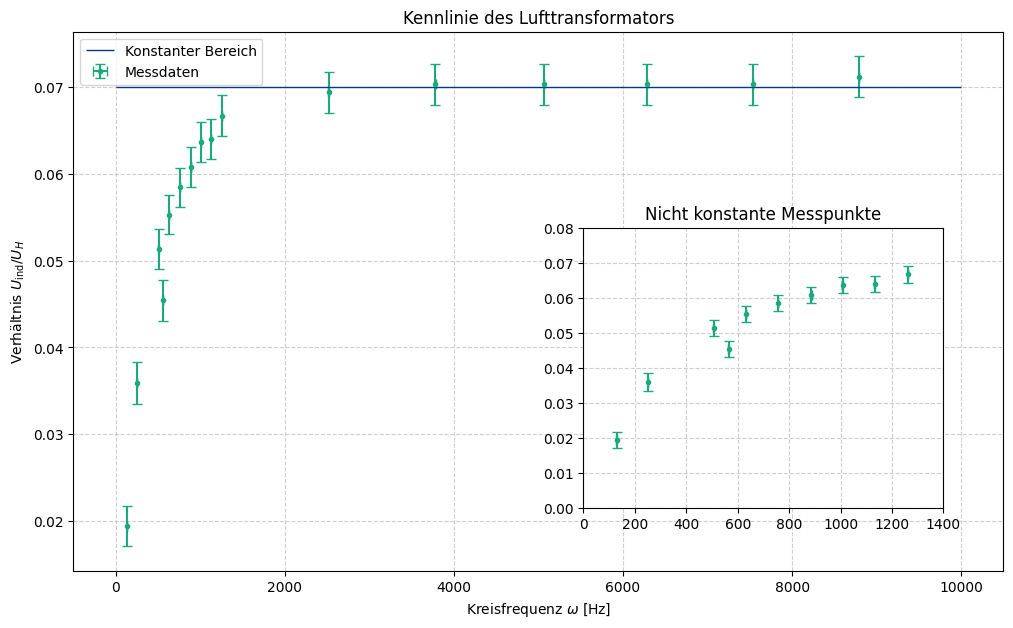

In [191]:
plt.figure(figsize=(12,7))

plt.errorbar(
    freq_A3,
    val,
    err,
    err_freq_A3,
    ls= ' ',
    capsize=3.5,
    label='Messdaten',
    marker = '.'
    ) 

plt.hlines(0.07, 0, 1e4,
           label='Konstanter Bereich',
           colors=c.BLUE,
           lw = 1
           )

plt.title('Kennlinie des Lufttransformators')
plt.xlabel(r'Kreisfrequenz $\omega$ [Hz]')
plt.ylabel(r'Verhältnis $U_\text{ind}/U_H$')

plt.legend()

# Small Window
plt.axes([.55, .20, .3, .4], facecolor = 'white')

# Messurment data
plt.errorbar(
    freq_A3[:10],
    val[:10],
    err[:10],
    err_freq_A3,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5
    )


plt.xlim(0, 1.4e3)
plt.ylim(0, 0.08)
plt.title('Nicht konstante Messpunkte')
plt.grid(alpha = 0.6)

plt.savefig(fr'{plt_save_folder}Kennlinie_Luft.pdf')
plt.show()


In [192]:
wid_stand = sym.U / sym.I

values = np.column_stack([
    U_M_A3, [err_U_M] * len(U_M_A3),
    I_A3, [err_I_A3] * len(I_A3)
])

temp = pap.do_it(wid_stand, [sym.U, sym.I], values, print_formula=True)
val_R = temp[:,0]
err_R = temp[:,1]

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------


Steigung: (1.944 \pm 0.010) 10^-4 H


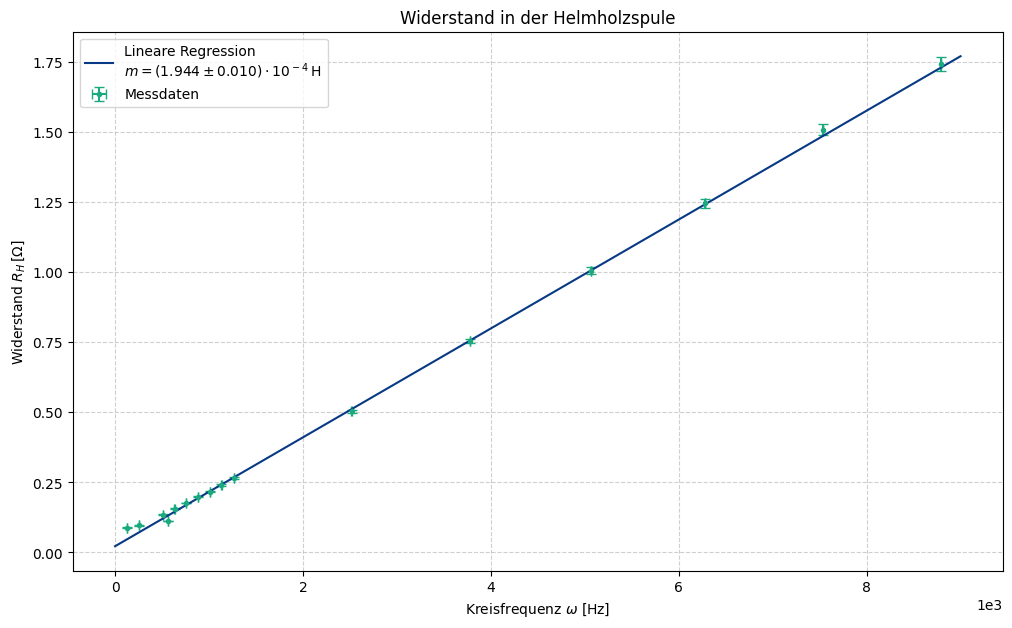

<Axes: title={'center': 'Widerstand in der Helmholzspule'}, xlabel='Kreisfrequenz $\\omega$ [Hz]', ylabel='Widerstand $R_H \\, [\\mathrm{\\Omega}]$'>

In [193]:
plt.figure(figsize=(12,7))

plt.errorbar(
    freq_A3,
    val_R,
    err_R,
    err_freq_A3,
    ls= ' ',
    capsize=3.5,
    label='Messdaten',
    marker = '.'
    ) 


# Regression
start, end = 2, len(freq_A3)
popt_neu, pcov_neu = curve_fit(linear, freq_A3[start:end], val_R[start:end], sigma = err_R[start:end], absolute_sigma = True)
m_R = popt_neu[0]
err_m_R = np.sqrt(pcov_neu[0][0])

expo = 1e4
print(f"Steigung: ({pap.round_sig_digs(err_m_R * expo, m_R * expo)[2]}) 10^-{(len(str(expo)) - 3)} H")


freq_sapce = np.linspace(0, 9e3, 100)
plt.plot(
    freq_sapce,
    linear(freq_sapce, * popt_neu),
    label = f'Lineare Regression\n$m=({pap.round_sig_digs(err_m_R * expo, m_R * expo)[2]}) \\cdot {{10^-}}^{(len(str(expo)) - 3)} \\, \\mathrm{{H}}$'
)

pap.plot_me('Widerstand in der Helmholzspule', r'Kreisfrequenz $\omega$ [Hz]', r'Widerstand $R_H \, [\mathrm{\Omega}]$', fr'{plt_save_folder}Widerstand')

<hr>

## Aufgabe 4

In [194]:
# Messung ohne Kompensation
dreh_frq_f0 = 11 * (2 * np.pi) # Hz
err_dreh_frq_f0 = 0.05 * (2 * np.pi) # Hz

Induk_spann = 0.13/2 # V
err_Induk_spann = 0.05/2 # V

# Messung mit Kompensation
kompen_I = 69.9e-3 # A
err_kompen_I = 0.05e-3 # A

rest_Induk_spann = 30/2 * 1e-3 # V
err_rest_Induk_spann = 5/2 * 1e-3 # V

In [195]:
# Bestimmung des Widerstandes in der HH-Spule
func = sym.U/sym.I

values = np.array([
    rest_Induk_spann, err_rest_Induk_spann,
    kompen_I, err_kompen_I 
])

temp = pap.do_it(func, [sym.U, sym.I], values, [], False)

wid_A4 = temp[:,0][0]
err_wid_A4 = temp[:,1][0]

In [196]:
Uind, w, N, A = sp.symbols('U_\\text{ind}, \\omega, N, A')

mag_feld = Uind / (A*N*w)

values = np.column_stack([
    Induk_spann, err_Induk_spann,
    dreh_frq_f0, err_dreh_frq_f0,
    n_I,
    A_I,
])

temp = pap.do_it(mag_feld, [Uind, w, N, A], values, [N, A], True)
B_abs = temp[:,0][0]
err_B_abs = temp[:,1][0]

expo = 1e5
print(f'Absolute Magnetfeldstärke: ({pap.round_sig_digs(err_B_abs * expo, B_abs * expo)[2]}) 10^{-(len(str(expo)) - 3)} T')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
Absolute Magnetfeldstärke: (5.6 \pm 2.2) 10^-5 T


In [197]:
# vergleich mit lit Wert
lit_mag_HD = 49e-6 # T

pap.std_abw(lit_mag_HD, B_abs, err_B_abs)

np.float64(0.34)

In [198]:
# bestimmung der Verrtikalkomponente
verti = sym.mu * sym.N * (sym.I / sym.R) *  (8/sp.sqrt(125))

values = np.array([
    kompen_I, err_kompen_I,
    r_H,
    const.mu_0,
    n_H
])

temp = pap.do_it(verti, [sym.I, sym.R, sym.mu, sym.N], values, [sym.R, sym.mu, sym.N], True)
B_ver = temp[:,0][0]
err_B_ver = temp[:,1][0]

expo = 1e5
print(f'Vertikale Feldstärke: ({pap.round_sig_digs(err_B_ver * expo, B_ver * expo)[2]}) 10^{-(len(str(expo)) - 3)} T')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
Vertikale Feldstärke: (5.412 \pm 0.004) 10^-5 T


In [199]:
# bestimmung der Horiziontalkomponente
hori = sym.U / (sym.A * sym.N * sym.f)

values = np.array([
    rest_Induk_spann, err_rest_Induk_spann,
    dreh_frq_f0, err_dreh_frq_f0,
    A_H,
    n_H
])


temp = pap.do_it(hori, [sym.U, sym.f, sym.A, sym.N], values, [sym.N, sym.A], True)

B_hor = temp[:,0][0]
err_B_hor = temp[:,1][0]

expo = 1e5
print(f'Horizontale Feldstärke: ({pap.round_sig_digs(err_B_hor * expo, B_hor * expo)[2]}) 10^{-(len(str(expo)) - 3)} T')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
Horizontale Feldstärke: (2.5 \pm 0.4) 10^-5 T


In [200]:
# prüfen:
B_abs_neu = sqrt(B_ver**2 + B_hor**2)
err_B_abs_neu = sqrt(err_B_ver**2 + err_B_hor**2)
expo = 1e5

print(pap.round_sig_digs(err_B_abs_neu * expo, B_abs_neu * expo)[2])
print(pap.std_abw(B_abs_neu, B_abs, err_B_abs_neu, err_B_abs))

6.0 \pm 0.4
0.15


In [201]:
ink_winkel = sp.atan(sym.v/sym.h) *360/(2*sp.pi)

values = np.array([
    B_ver, err_B_ver,
    B_hor, err_B_hor
])

temp = pap.do_it(ink_winkel, [sym.v, sym.h], values, [], False)

alpha = temp[:,0][0]
err_alpha = temp[:,1][0]

print(f'Der Inklinationswinkel liegt bei: {pap.round_sig_digs(err_alpha, alpha)[2]}')

Der Inklinationswinkel liegt bei: 65 \pm 4


In [202]:
pap.std_abw(alpha, 65, 4)

np.float64(0.05)